In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
%matplotlib inline

In [84]:
df_customer_churn = pd.read_csv("customer_churn.csv")
df_customer_churn

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0
...,...,...,...,...,...,...,...,...,...
495,C00496,50,128,6970,Month-to-month,Credit Card,Yes,1,0
496,C00497,2,49,5917,Two year,Bank Transfer,No,1,0
497,C00498,46,198,2158,Month-to-month,Bank Transfer,No,0,0
498,C00499,1,185,5755,Two year,Credit Card,Yes,1,1


In [5]:
df_sales_data = pd.read_csv("sales_data.csv")
df_sales_data

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680
...,...,...,...,...,...,...,...
95,2024-04-05,Tablet,8,20770,CUST096,North,166160
96,2024-04-06,Headphones,1,7647,CUST097,West,7647
97,2024-04-07,Tablet,5,27196,CUST098,East,135980
98,2024-04-08,Monitor,1,30717,CUST099,North,30717


In [7]:
df_customer_churn.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [8]:
df_sales_data.isnull().sum()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

# <b>Analysis of Sales

In [14]:
df_sales_data_cp = df_sales_data.copy()

<b><p>We will split the Date column into year, month and day which can be later used to analyse the monthly trends for sales, orders, etc.</b>

In [19]:
df_sales_data_cp[["Year", "Month", "Day"]] = df_sales_data_cp["Date"].str.split("-", expand=True)
df_sales_data_cp.drop(["Date"], axis=1, inplace=True)
df_sales_data_cp.head()

,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day
0,Phone,7,37300,CUST001,East,261100,2024,01,01
1,Headphones,4,15406,CUST002,North,61624,2024,01,02
2,Phone,2,21746,CUST003,West,43492,2024,01,03
3,Headphones,1,30895,CUST004,East,30895,2024,01,04
4,Laptop,8,39835,CUST005,North,318680,2024,01,05


## Executive Summary

In [154]:
print("CUSTOMER SALES ANALYSIS REPORT:")
tot_rev = df_sales_data_cp["Price"].sum()
print(f"Total Revenue : ${tot_rev}")
tot_cus = df_sales_data_cp["Customer_ID"].nunique()
print(f"Total Customers : {tot_cus}")
avg_order_val = df_sales_data_cp["Total_Sales"].mean()
print(f"Average Order Value : ${avg_order_val}")
top_cus = df_sales_data_cp.loc[df_sales_data_cp["Price"].idxmax(), "Customer_ID"]
top_sale = df_sales_data["Price"].max()
print(f"Top Customers : {top_cus} with sale of ${top_sale}")

CUSTOMER SALES ANALYSIS REPORT:
Total Revenue : $2580851
Total Customers : 100
Average Order Value : $123650.48
Top Customers : CUST073 with sale of $49930


## Monthly Sales

In [69]:
df_monthly_sales = df_sales_data_cp.groupby("Month").agg(
    monthly_sales = ("Total_Sales", "sum") ,
    no_orders = ("Customer_ID", "nunique") ,
    quantity = ("Quantity", "sum")
)
df_monthly_sales

,monthly_sales,no_orders,quantity
Month,,,
01,4120524,31,147
02,2656050,29,112
03,4485006,31,175
04,1103468,9,44


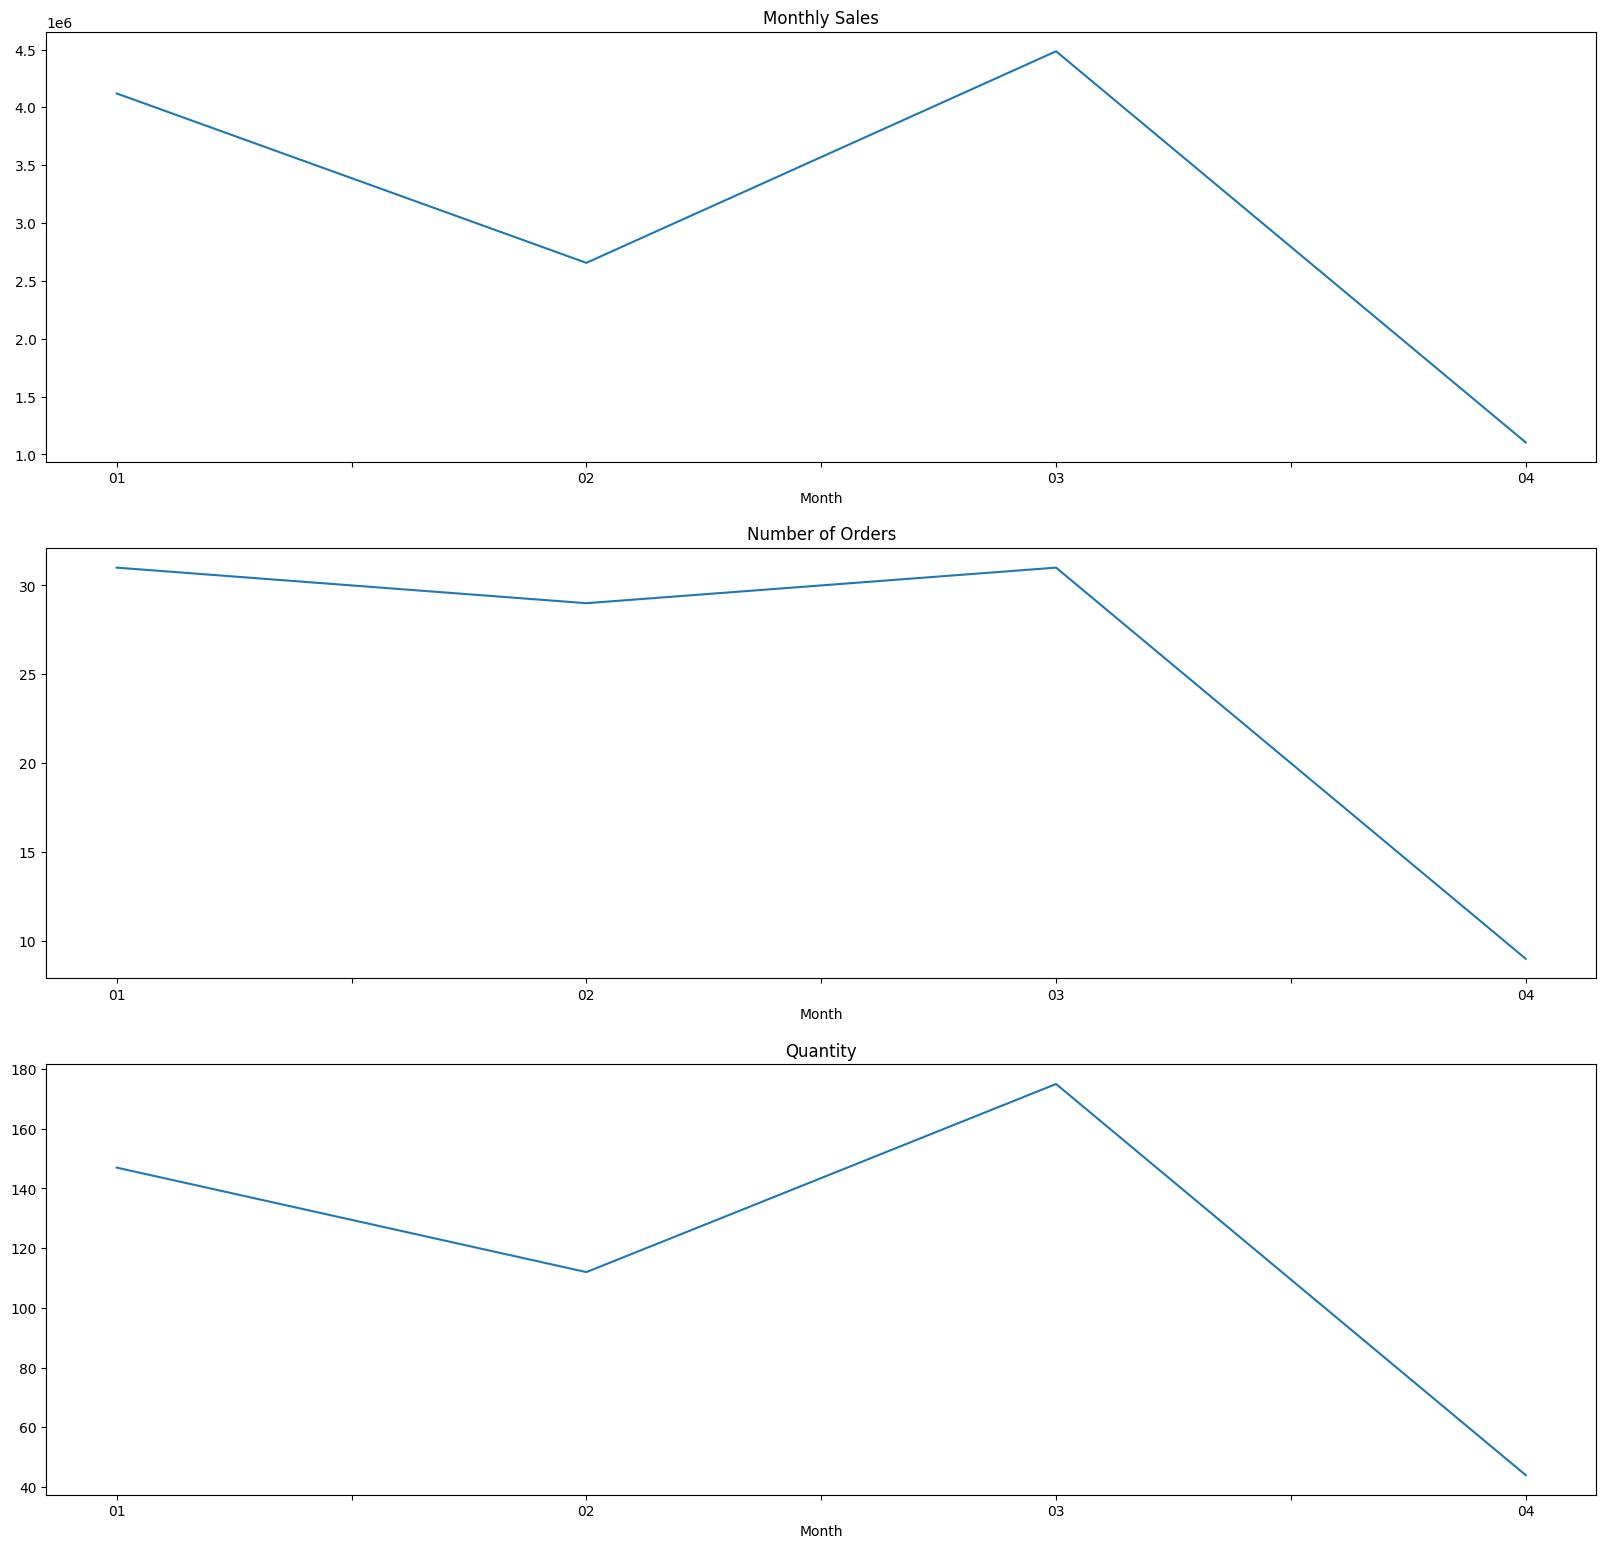

In [65]:
plt.figure(figsize=(20,19))

plt.subplot(3,1,1)
df_monthly_sales["monthly_sales"].plot(kind="line")
plt.title("Monthly Sales")

plt.subplot(3,1,2)
df_monthly_sales['no_orders'].plot(kind="line")
plt.title("Number of Orders")

plt.subplot(3,1,3)
df_monthly_sales["quantity"].plot(kind="line")
plt.title("Quantity")
plt.show()

## Product Category Sales

In [37]:
df_product = df_sales_data_cp.groupby(["Month", "Product"]).agg(
    monthly_sales = ("Price", "sum") ,
    monthly_orders = ("Customer_ID", "nunique")
). 
df_product

monthly_sales  monthly_orders
Month Product                                  
01    Headphones         148248               6
      Laptop             306460               9
      Monitor             15351               2
      Phone              147970               6
      Tablet             231466               8
02    Headphones          46148               2
      Laptop              91620               3
      Monitor            195898               8
      Phone              209322               8
      Tablet             179183               8
03    Headphones         162150               4
      Laptop             248889              11
      Monitor             68679               4
      Phone              190288               6
      Tablet             119955               6
04    Headphones          73836               3
      Laptop              16667               1
      Monitor             30717               1
      Tablet              98004               4

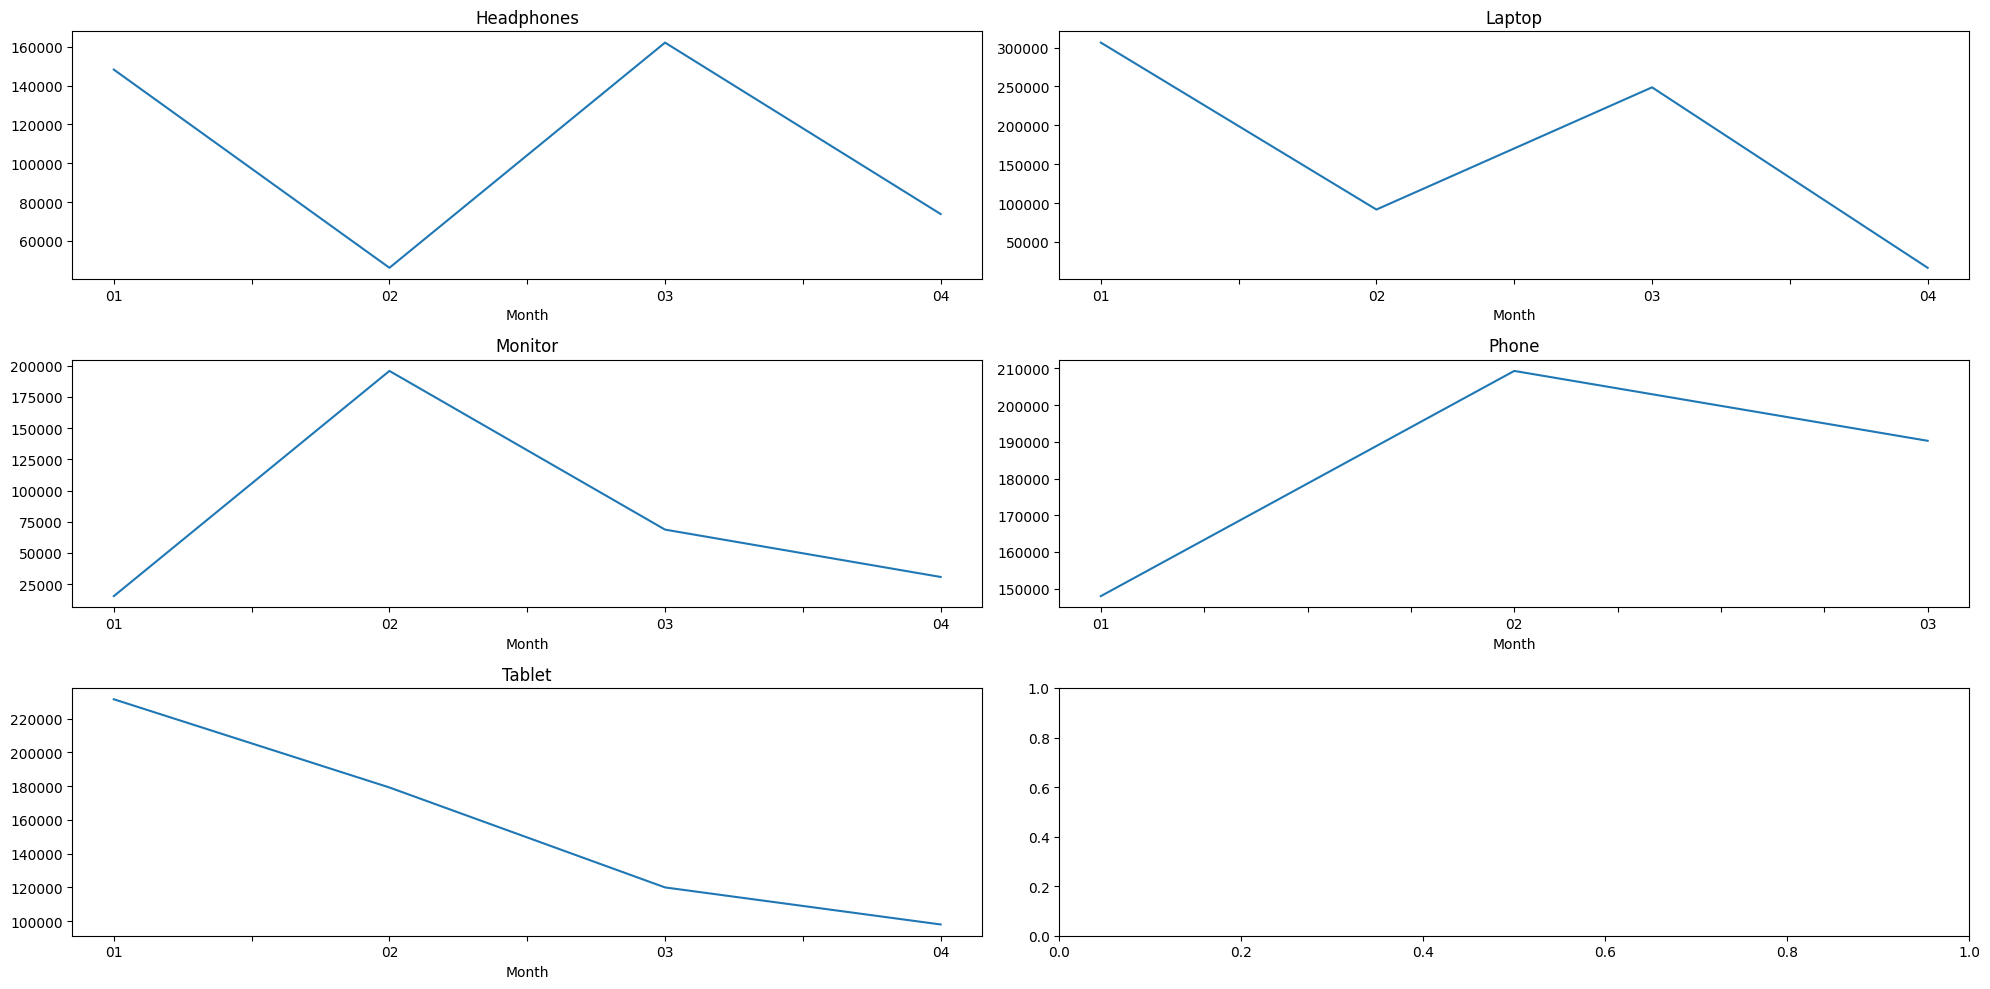

In [40]:
headphones_sales = df_product.xs('Headphones', level='Product')
laptop_sales = df_product.xs('Laptop', level='Product')
monitor_sales = df_product.xs('Monitor', level='Product')
phone_sales = df_product.xs('Phone', level='Product')
tablet_sales = df_product.xs('Tablet', level='Product')

fig, axes = plt.subplots(3, 2, figsize=(20,10))

headphones_sales["monthly_sales"].plot(kind='line', ax=axes[0,0], title="Headphones")
laptop_sales["monthly_sales"].plot(kind='line', ax=axes[0,1], title="Laptop")
monitor_sales["monthly_sales"].plot(kind='line', ax=axes[1,0], title="Monitor")
phone_sales["monthly_sales"].plot(kind='line', ax=axes[1,1], title="Phone")
tablet_sales["monthly_sales"].plot(kind='line', ax=axes[2,0], title="Tablet")

plt.tight_layout()
plt.show()

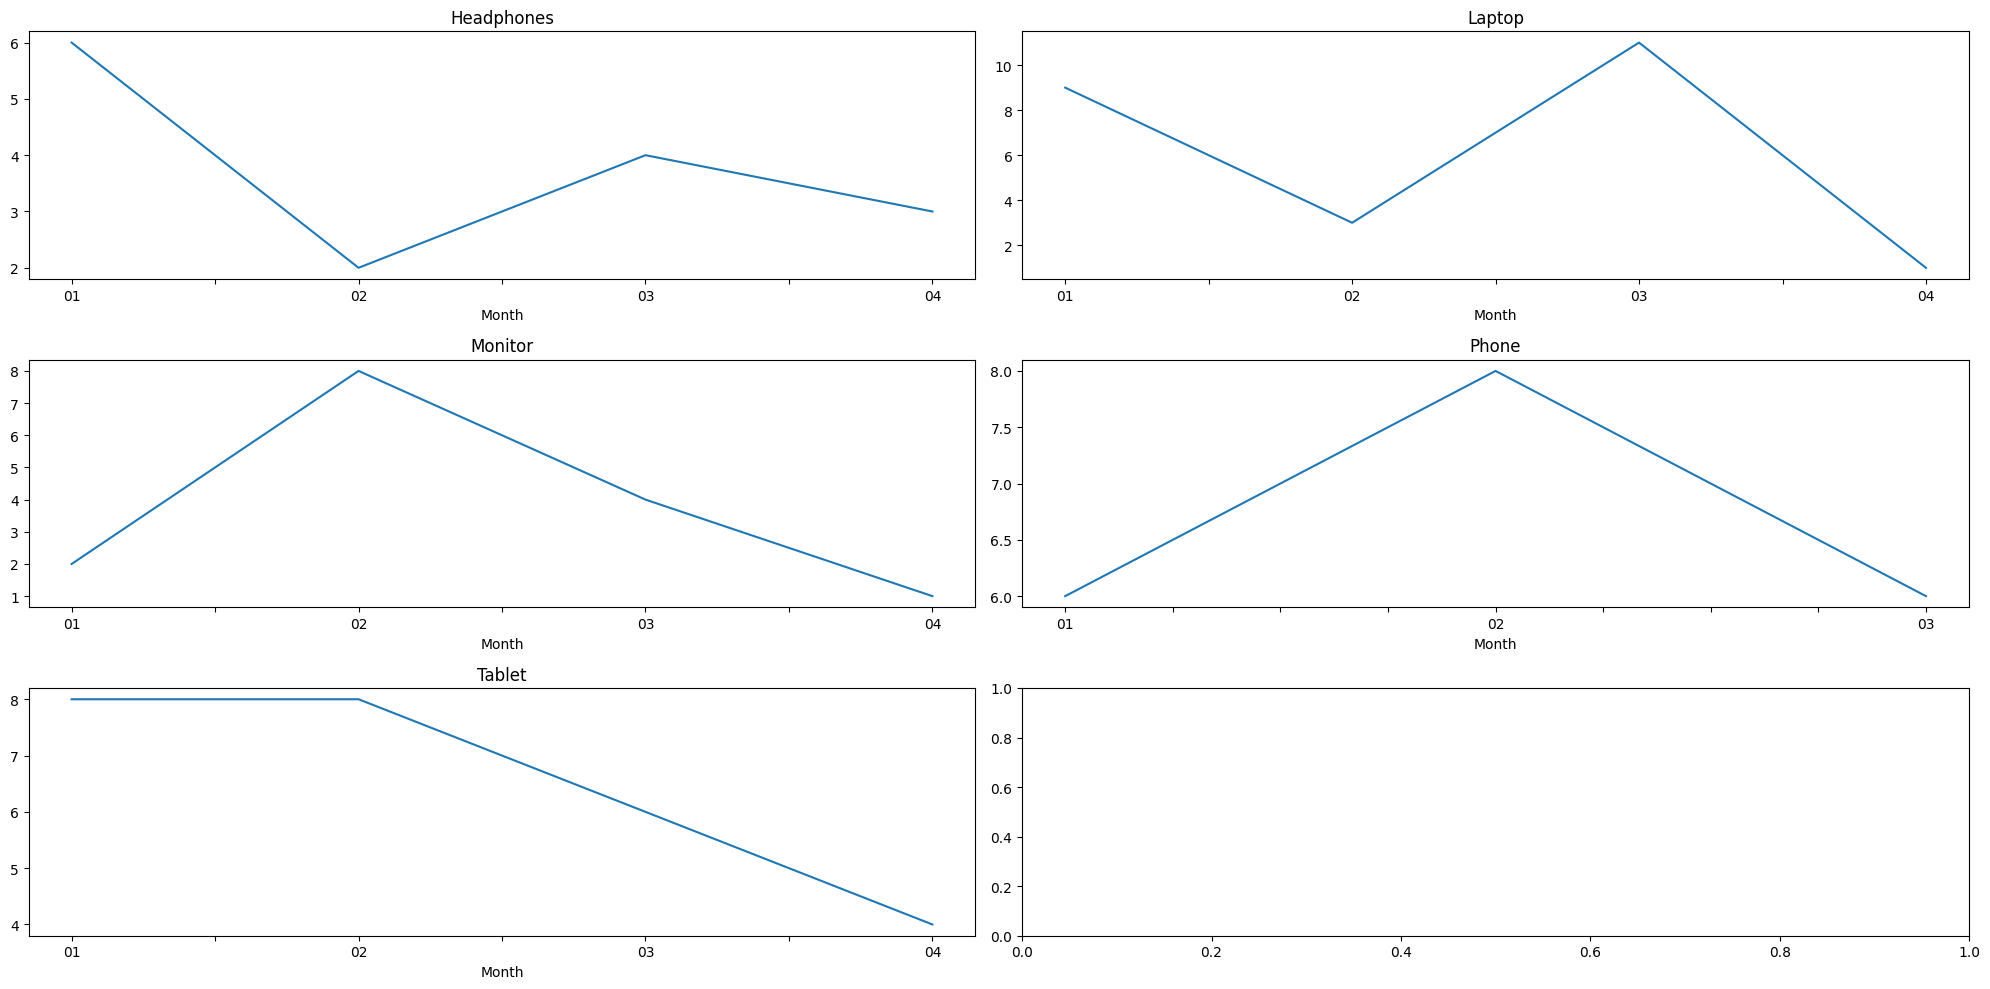

In [41]:
fig, axes = plt.subplots(3, 2, figsize=(20,10))

headphones_sales["monthly_orders"].plot(kind='line', ax=axes[0,0], title="Headphones")
laptop_sales["monthly_orders"].plot(kind='line', ax=axes[0,1], title="Laptop")
monitor_sales["monthly_orders"].plot(kind='line', ax=axes[1,0], title="Monitor")
phone_sales["monthly_orders"].plot(kind='line', ax=axes[1,1], title="Phone")
tablet_sales["monthly_orders"].plot(kind='line', ax=axes[2,0], title="Tablet")

plt.tight_layout()
plt.show()

## Region Wise Sales

In [68]:
df_region_monthly_sales = df_sales_data_cp.groupby(["Month", "Region"]).agg(
    monthly_sales = ("Total_Sales", "sum") ,
    no_orders = ("Customer_ID", "nunique") ,
    quantity = ("Quantity", "sum")    
)
df_region_monthly_sales

monthly_sales  no_orders  quantity
Month Region                                    
01    East           792969          6        29
      North         1726624         11        57
      South         1088182          4        30
      West           512749         10        31
02    East           746674          6        24
      North          640784          5        25
      South          422941          9        34
      West           845651          9        29
03    East           844016          6        36
      North         1419350         10        56
      South         1600314         10        57
      West           621326          5        26
04    East           135980          1         5
      North          196877          2         9
      South          626415          4        22
      West           144196          2         8

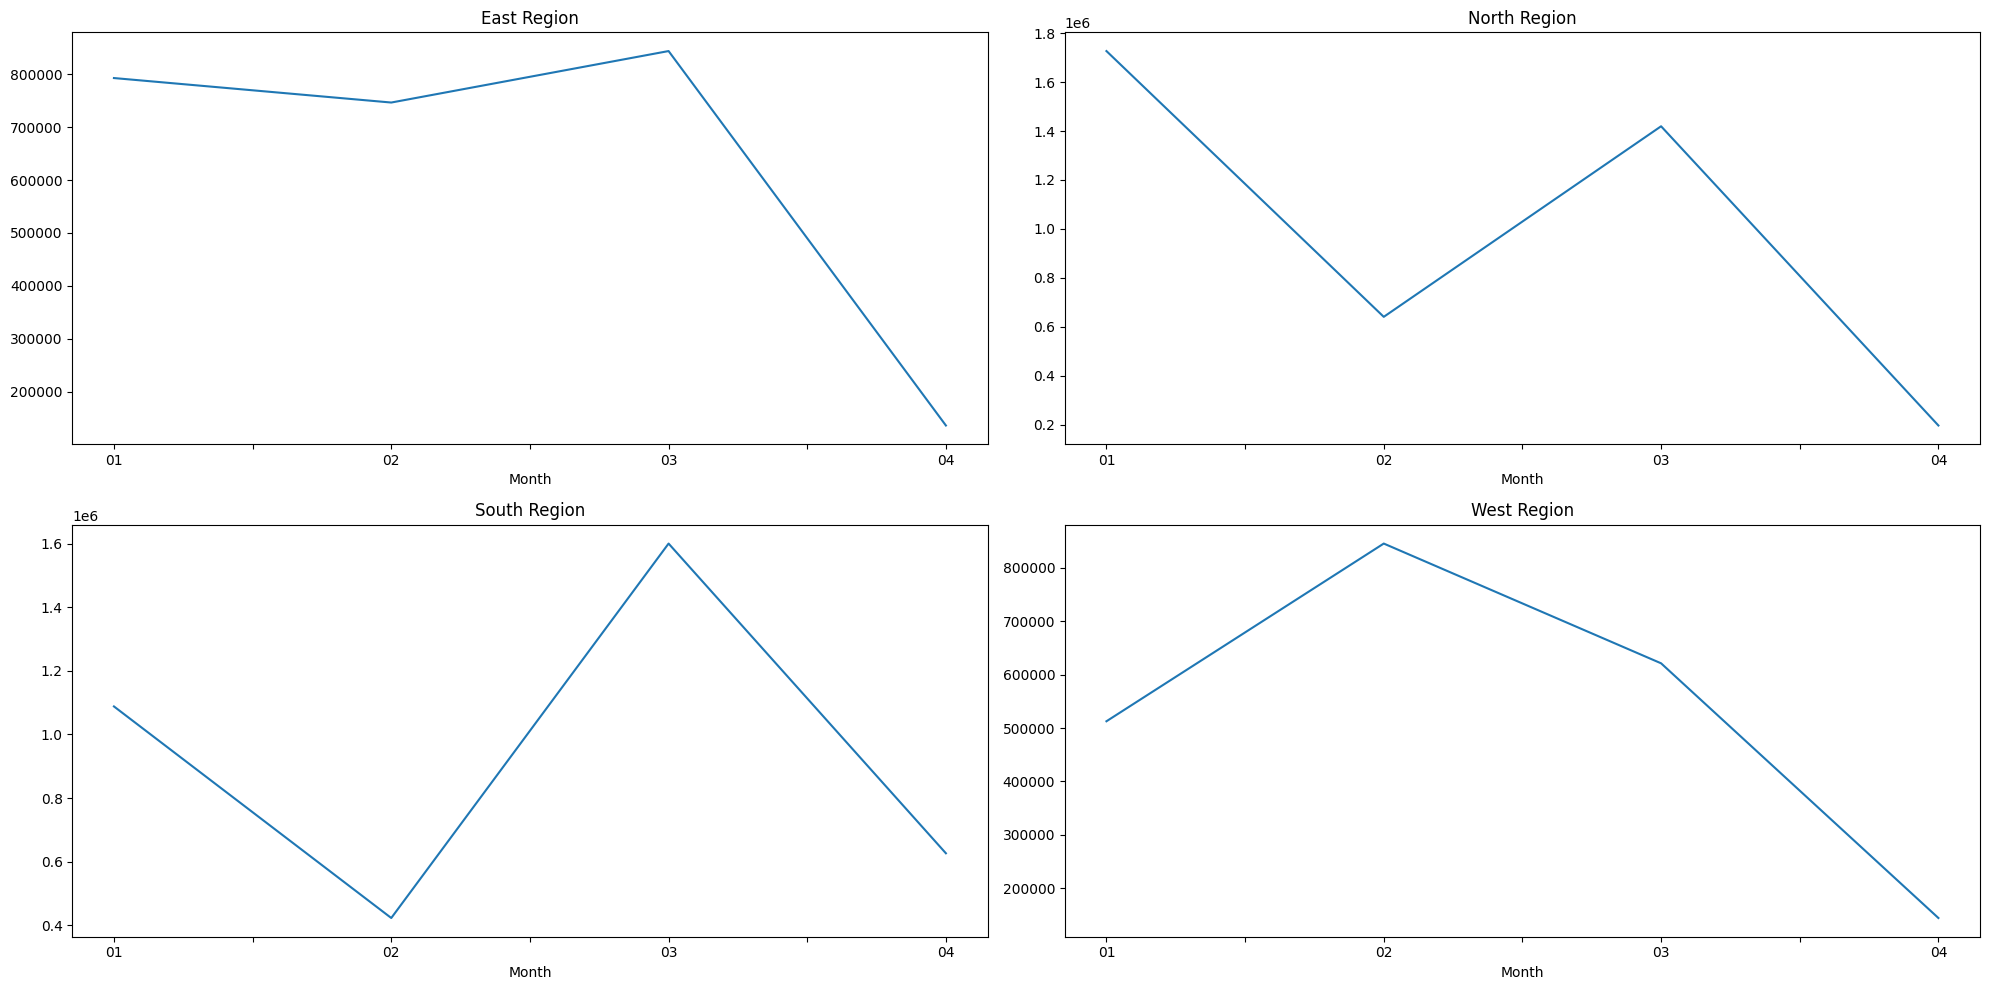

In [71]:
east_region_sales = df_region_monthly_sales.xs('East', level='Region')
north_region_sales = df_region_monthly_sales.xs('North', level='Region')
south_region_sales = df_region_monthly_sales.xs('South', level='Region')
west_region_sales = df_region_monthly_sales.xs('West', level='Region')

fig, axes = plt.subplots(2, 2, figsize=(20,10))

east_region_sales["monthly_sales"].plot(kind='line', ax=axes[0,0], title="East Region")
north_region_sales["monthly_sales"].plot(kind='line', ax=axes[0,1], title="North Region")
south_region_sales["monthly_sales"].plot(kind='line', ax=axes[1,0], title="South Region")
west_region_sales["monthly_sales"].plot(kind='line', ax=axes[1,1], title="West Region")

plt.tight_layout()
plt.show()

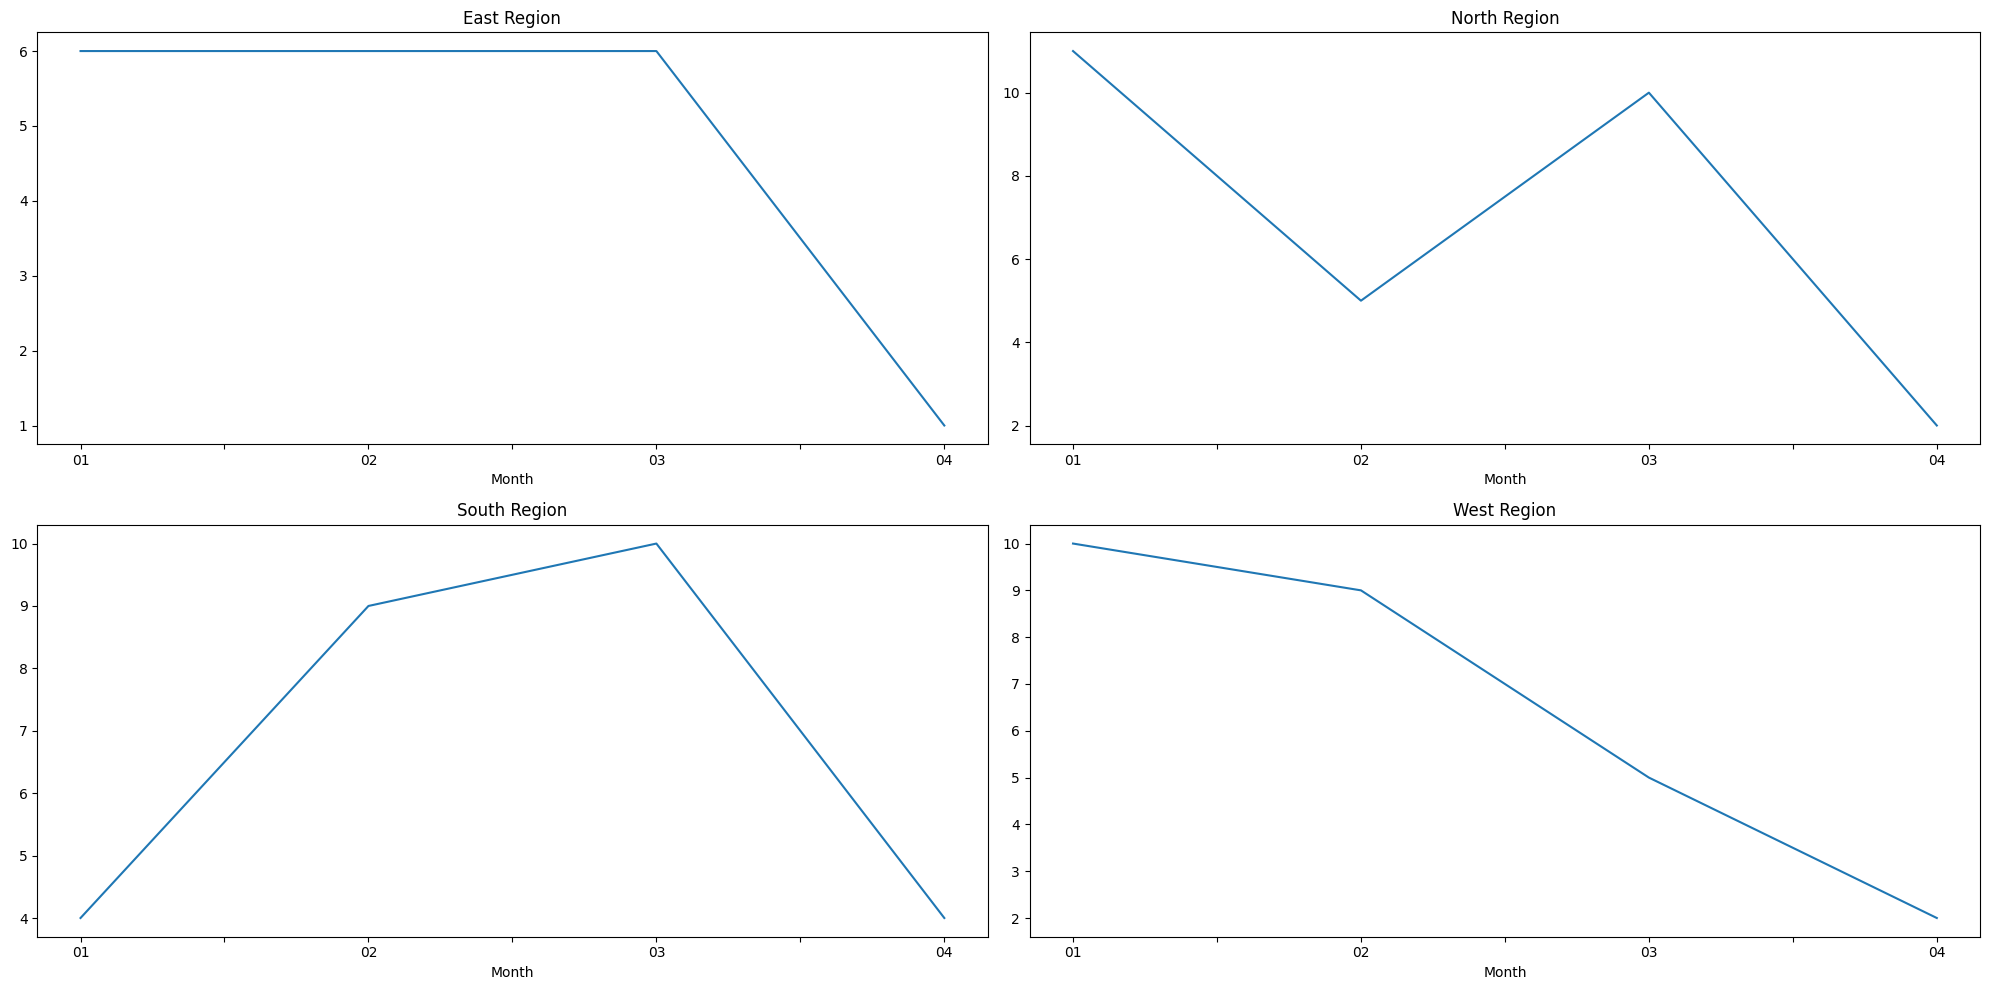

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(20,10))

east_region_sales["no_orders"].plot(kind='line', ax=axes[0,0], title="East Region")
north_region_sales["no_orders"].plot(kind='line', ax=axes[0,1], title="North Region")
south_region_sales["no_orders"].plot(kind='line', ax=axes[1,0], title="South Region")
west_region_sales["no_orders"].plot(kind='line', ax=axes[1,1], title="West Region")

plt.tight_layout()
plt.show()

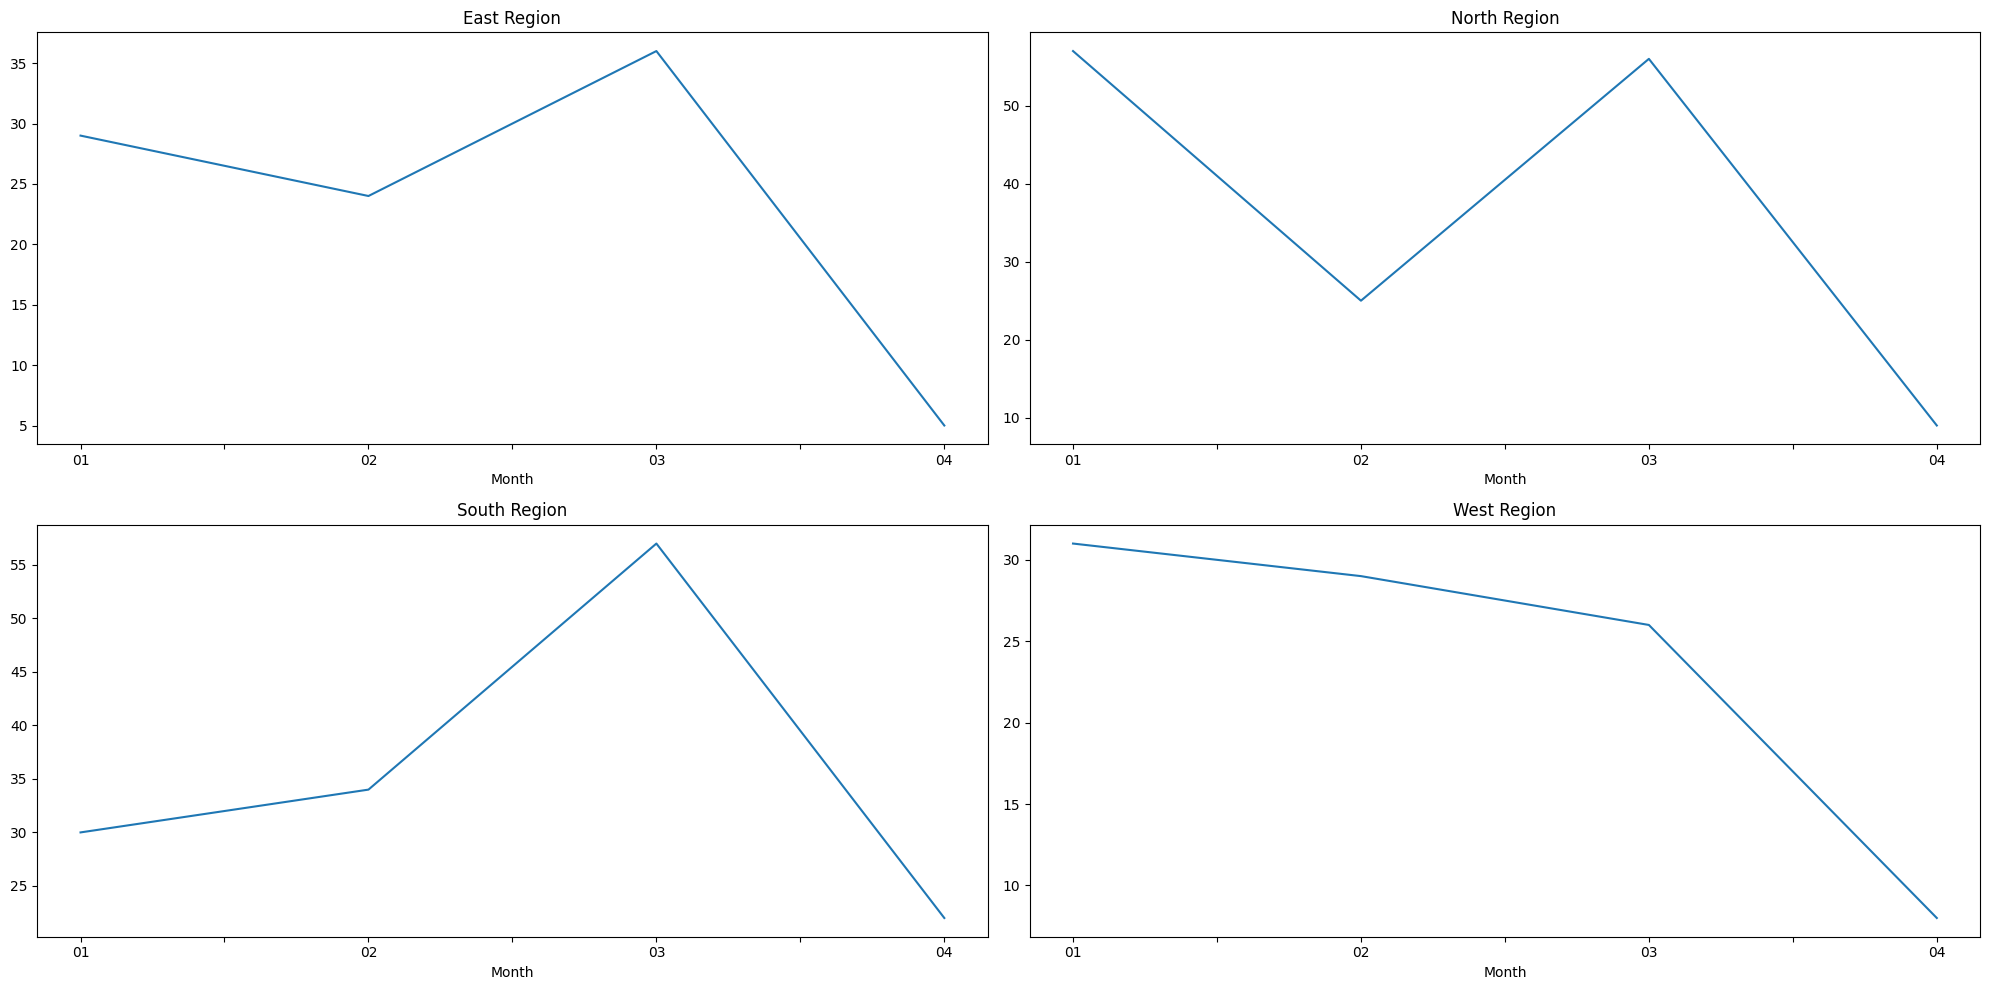

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(20,10))

east_region_sales["quantity"].plot(kind='line', ax=axes[0,0], title="East Region")
north_region_sales["quantity"].plot(kind='line', ax=axes[0,1], title="North Region")
south_region_sales["quantity"].plot(kind='line', ax=axes[1,0], title="South Region")
west_region_sales["quantity"].plot(kind='line', ax=axes[1,1], title="West Region")

plt.tight_layout()
plt.show()

# <b>Analysis of Customer Churn

In [78]:
df_customer_churn_cp = df_customer_churn.copy()

## Analysis of Churned Customers

In [118]:
p_churned = (len(df_customer_churn_cp[df_customer_churn_cp["Churn"]==1].index)/ df_customer_churn.shape[0])*100
print(f"\033[1m %age of Customers Churned: {p_churned}%\033[0m")

 %age of Customers Churned: 10.6%


In [119]:
df_churned = df_customer_churn_cp[df_customer_churn_cp["Churn"]==1]
df_churned.head(20)

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
11,C00012,7,110,7282,Month-to-month,Electronic Check,No,1,1
13,C00014,8,158,6194,Month-to-month,Credit Card,No,1,1
18,C00019,7,156,5389,One year,Bank Transfer,Yes,0,1
31,C00032,10,196,4825,Month-to-month,Credit Card,Yes,0,1
54,C00055,9,157,7022,Month-to-month,Bank Transfer,No,0,1
61,C00062,10,195,4284,Two year,Electronic Check,No,0,1
68,C00069,2,102,1333,Two year,Credit Card,Yes,0,1
73,C00074,2,152,2038,Month-to-month,Bank Transfer,No,0,1
76,C00077,4,43,7302,Month-to-month,Credit Card,Yes,0,1
98,C00099,10,143,3353,Two year,Electronic Check,No,1,1


<u><p>
%age of Customers churned whose contract were "Month-to-month":
</u>

In [111]:
round(float((len(df_churned[df_churned["Contract"]=="Month-to-month"].index)/len(df_churned.index))*100), 2)

66.04

<u><p>
%age of Customers churned whose contract were "One year" :
</u>

In [112]:
round(float((len(df_churned[df_churned["Contract"]=="One year"].index)/len(df_churned.index))*100), 2)

15.09

<u><p>
%age of Customers churned whose contract were "Two year":
</u>

In [113]:
round(float((len(df_churned[df_churned["Contract"]=="Two year"].index)/len(df_churned.index))*100), 2)

18.87

<b><p>
Most of the churned customers were on a month-to month contract.
</b>

In [161]:
df_churned[df_churned["Contract"]=="Month-to-month"].head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
11,C00012,7,110,7282,Month-to-month,Electronic Check,No,1,1
13,C00014,8,158,6194,Month-to-month,Credit Card,No,1,1
31,C00032,10,196,4825,Month-to-month,Credit Card,Yes,0,1
54,C00055,9,157,7022,Month-to-month,Bank Transfer,No,0,1
73,C00074,2,152,2038,Month-to-month,Bank Transfer,No,0,1


<b><p>
I am comparing the monthly charges for each contract type.
</b>

For One-year Contract:

In [128]:
df_churned[df_churned["Contract"]=="One year"]

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
18,C00019,7,156,5389,One year,Bank Transfer,Yes,0,1
139,C00140,2,184,5021,One year,Electronic Check,Yes,1,1
146,C00147,6,133,7448,One year,Credit Card,No,0,1
150,C00151,5,105,5965,One year,Credit Card,No,0,1
171,C00172,10,115,3717,One year,Electronic Check,Yes,0,1
352,C00353,6,137,4804,One year,Electronic Check,Yes,0,1
361,C00362,5,134,3651,One year,Credit Card,Yes,1,1
463,C00464,10,168,5667,One year,Electronic Check,Yes,1,1


In [131]:
df_churned[df_churned["Contract"]=="One year"]["MonthlyCharges"].mean()

np.float64(141.5)

For Two-year Contract:

In [129]:
df_churned[df_churned["Contract"]=="Two year"]

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
61,C00062,10,195,4284,Two year,Electronic Check,No,0,1
68,C00069,2,102,1333,Two year,Credit Card,Yes,0,1
98,C00099,10,143,3353,Two year,Electronic Check,No,1,1
104,C00105,3,115,5547,Two year,Bank Transfer,No,0,1
129,C00130,8,174,3979,Two year,Credit Card,Yes,0,1
141,C00142,11,115,1713,Two year,Bank Transfer,Yes,1,1
251,C00252,9,138,515,Two year,Credit Card,No,0,1
457,C00458,1,186,622,Two year,Electronic Check,Yes,1,1
479,C00480,11,160,4666,Two year,Credit Card,No,0,1
498,C00499,1,185,5755,Two year,Credit Card,Yes,1,1


In [132]:
df_churned[df_churned["Contract"]=="Two year"]["MonthlyCharges"].mean()

np.float64(151.3)

## Analysis of Payment Methods

In [160]:
total_sales = df_customer_churn_cp["TotalCharges"].sum()
r = df_customer_churn_cp.groupby("PaymentMethod").agg(
    revenue = ("TotalCharges", "sum") 
).sort_values(by="revenue", ascending=False)
r["%_of_total"] = round((r["revenue"]/total_sales)*100, 2)
r

,revenue,%_of_total
PaymentMethod,,
Credit Card,769015,36.29
Electronic Check,685698,32.36
Bank Transfer,664228,31.35


<Axes: xlabel='PaymentMethod'>

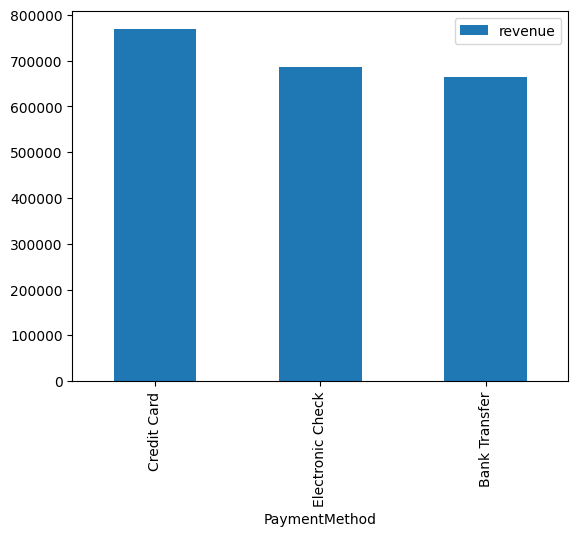

In [140]:
df_customer_churn_cp.groupby("PaymentMethod").agg(
    revenue = ("TotalCharges", "sum")
).sort_values(by="revenue", ascending=False).plot(kind="bar")

## Senior Citizen Analysis

<Axes: xlabel='SeniorCitizen'>

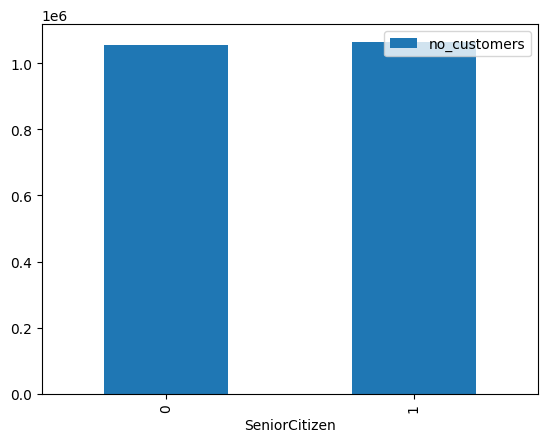

In [145]:
df_customer_churn_cp.groupby("SeniorCitizen").agg(
    no_customers = ("TotalCharges", "sum")
).plot(kind="bar")